---
format:
  html:
    code-fold: false
execute:
  echo: true
---

[![](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MatthewAlexanderFisher/NCL-MAS3919/blob/main/content/practicals/2-ml-models-in-pytorch.ipynb)


# Machine Learning Models in PyTorch {#sec-practical-pytorch-models}

In this practical, we explore how to implement different **machine learning models** using PyTorch.

Unlike NumPy, PyTorch is not just a library for numerical computation: it is a complete framework for building, training, and optimising machine learning models.

## Recap

In the previous practical, we introduced the basics of PyTorch. The key idea is that PyTorch is very similar to NumPy, so most of your existing knowledge transfers directly.

- **Tensors** (`torch.tensor`) play the same role as Numpy arrays (`np.array`).
- Most familiar **array operations** (indexing, slicing, broadcasting, matrix multiplication, etc.) work in the same way.

However, PyTorch provides several additional features that are essential for machine learning:

1. **Model Abstraction.** PyTorch provides a framework for defining machine learning models in a standardised way.
2.  **Automatic Differentiation.** PyTorch can automatically compute derivatives of functions. This allows us to calculate gradients needed for training models.
3. **Optimisation.** PyTorch includes built-in optimisation algorithms (such as gradient descent) for training models.

These features allow us to move from simply performing numerical calculations to building and training predictive models.

In this practical, we focus on **PyTorch's modelling framework**.

### Key Syntax

In [6]:
import torch              # Import the main PyTorch library
import torch.nn as nn    # Import PyTorch's neural network module

# Defining a tensor
x = torch.tensor([1.0, 2.0, 3.0], dtype=torch.float32)
print("x:", x)

# Creating random tensors with different shapes
A = torch.randn(2, 3)   # 2 × 3 matrix
B = torch.randn(3, 4)   # 3 × 4 matrix
C = torch.randn(4, 5)   # 4 × 5 matrix
D = torch.randn(5, 6)   # 5 × 6 matrix

# Print shapes
print("A shape:", A.shape)
print("B shape:", B.shape)
print("C shape:", C.shape)
print("D shape:", D.shape)

# Common operation: matrix multiplication
result = A @ B

print("Result shape:", result.shape)

x: tensor([1., 2., 3.])
A shape: torch.Size([2, 3])
B shape: torch.Size([3, 4])
C shape: torch.Size([4, 5])
D shape: torch.Size([5, 6])
Result shape: torch.Size([2, 4])


Matrix multiplication is only defined when the inner dimensions match. For example, a $(2 \times 3)$ matrix can be multiplied by a $(3 \times 4)$ matrix, producing a $(2 \times 4)$ matrix.

## What is a model?

### Setting

In supervised learning, we distinguish three spaces:

- $\mathcal{X}$ — the **input space**
- $\mathcal{Y}$ — the **true label space**
- $\mathcal{Z}$ — the **prediction space**

We observe data of the form
$$
(\boldsymbol{x}, y) \in \mathcal{X} \times \mathcal{Y},
$$
typically sampled from some (unknown) distribution on $\mathcal{X} \times \mathcal{Y}$.

A learning algorithm produces a function
$$
f : \mathcal{X} \to \mathcal{Z},
$$
which maps inputs to predictions.

---

### Parametric Models

Following the course notes, a **model** is a *parametric class of functions*:
$$
\mathcal{F} = \{ f_{\boldsymbol{\theta}} \mid \boldsymbol{\theta} \in \Theta \},
$$
where:

- $\boldsymbol{\theta}$ is a **parameter vector**
- $\Theta$ is the **parameter space**
- each $f_{\boldsymbol{\theta}} : \mathcal{X} \to \mathcal{Z}$ is a function

Learning a model means choosing a parameter value
$$
\boldsymbol{\theta}^\ast \in \Theta
$$
based on observed data (typically by minimising empirical risk).

---

## Examples of Models

### Linear Models

A **linear model** has the form
$$
f_{\boldsymbol{\theta}}(\boldsymbol{x})
=
\theta_1 \phi_1(\boldsymbol{x})
+
\theta_2 \phi_2(\boldsymbol{x})
+
\ldots
+
\theta_p \phi_p(\boldsymbol{x}),
$$
where:

- $\phi_1, \ldots, \phi_p$ are **feature functions**
- $\boldsymbol{\theta} = (\theta_1, \ldots, \theta_p)$ are the parameters

The model is **linear in the parameters** $\boldsymbol{\theta}$ (though not necessarily linear in $\boldsymbol{x}$).

---

#### Example: Multiple Linear Regression

Suppose
$$
\boldsymbol{x} = (x_1, \ldots, x_p).
$$

If we choose $\phi_i(\boldsymbol{x}) = x_i$, then the standard linear regression model (without intercept) is
$$
f_{\boldsymbol{\theta}}(\boldsymbol{x})
=
\theta_1 x_1
+
\theta_2 x_2
+
\ldots
+
\theta_p x_p.
$$

In vector form, this can be written compactly as
$$
f_{\boldsymbol{\theta}}(\boldsymbol{x}) = \boldsymbol{\theta}^\top \boldsymbol{x}.
$$


### Feedforward Neural Network

A **feedforward neural network** generalises linear models by composing linear transformations with nonlinear functions.

A simple one-hidden-layer neural network has the form
$$
f_{\boldsymbol{\theta}}(\boldsymbol{x})
=
W_2 \, \sigma\!\left( W_1 \boldsymbol{x} + \boldsymbol{b}_1 \right)
+
\boldsymbol{b}_2,
$$
where:

- $W_1 \in \mathbb{R}^{m \times d}$ and $W_2 \in \mathbb{R}^{k \times m}$ are **weight matrices**
- $\boldsymbol{b}_1 \in \mathbb{R}^m$ and $\boldsymbol{b}_2 \in \mathbb{R}^k$ are **bias vectors**
- $\sigma$ is a **nonlinear activation function** (e.g. ReLU, sigmoid, tanh)
- $\boldsymbol{\theta}$ consists of *all* weights and biases

In contrast to linear models:

- The model is **not linear in the parameters**
- The nonlinear activation $\sigma$ allows the model to represent highly flexible functions


#### General Multi-Layer Form

A feedforward neural network with $L$ layers can be written recursively as

$$
\boldsymbol{h}^{(0)} = \boldsymbol{x},
$$

$$
\boldsymbol{h}^{(\ell)}
=
\sigma^{(\ell)}\!\left(
W^{(\ell)} \boldsymbol{h}^{(\ell-1)} + \boldsymbol{b}^{(\ell)}
\right),
\quad \ell = 1, \ldots, L,
$$

and the final output is

$$
f_{\boldsymbol{\theta}}(\boldsymbol{x})
=
\boldsymbol{h}^{(L)}.
$$

The parameter vector
$$
\boldsymbol{\theta}
=
\{ W^{(\ell)}, \boldsymbol{b}^{(\ell)} \}_{\ell=1}^L
$$
contains all weights and biases across layers.

#### Relationship to Linear Models

If we remove the nonlinearities (i.e. take $\sigma$ to be the identity function), then a multi-layer neural network collapses to a single linear transformation.

Thus:

- Linear regression is a special case of a neural network
- Neural networks extend linear models by introducing **nonlinearity and depth**


## PyTorch Models

In PyTorch, a model is a subclass of `nn.Module`  
(`nn` stands for *neural network*).

The general pattern is:

```python
import torch
import torch.nn as nn

class Model(nn.Module):

    def __init__(self):
        super().__init__()   # initialise the parent class

        # Define parameters here
        # Example:
        self.theta = nn.Parameter(torch.randn(1))

    def forward(self, x):
        # Define the function f_theta(x) here
        return self.theta * x
```

### Structure of a PyTorch model

A **PyTorch model** has the following structure:

* It is a **Python class**
* It **inherits** from `nn.Module`
* The `__init__` method defines the parameters (using `nn.Parameter`)
* The `forward` method defines the function $f_{\boldsymbol{\theta}}(\boldsymbol{x})$.

### Why `nn.Parameter`?

When we write

```python
self.theta = nn.Parameter(...)
```

we are telling PyTorch:

> "This tensor is a learnable parameter"

PyTorch will then:

* Automatically track it
* Compute gradients for it 
* Pass it to the optimiser when we train the model

If we just created a tensor using `torch.tensor(...)`, PyTorch would not treat it as a parameter of the model.


### Example: Simple Linear Regression

Suppose our model is

$$
f_{\boldsymbol{\theta}}(x)
=
\theta_0 + \theta_1 x.
$$

Here:

- $\theta_0$ is the intercept
- $\theta_1$ is the slope
- $\boldsymbol{\theta} = (\theta_0, \theta_1)$

We can implement this model directly in PyTorch:


In [ ]:
import torch
import torch.nn as nn

class SimpleLinear(nn.Module):

    def __init__(self):
        super().__init__()

        # Learnable parameters (randomly initialised)
        self.theta_0 = nn.Parameter(torch.randn(1))
        self.theta_1 = nn.Parameter(torch.randn(1))

    def forward(self, x):
        return self.theta_0 + self.theta_1 * x

#### Using the model

We instantiate the model:

In [ ]:
simple_model = SimpleLinear()

print("Initial parameters:",
      simple_model.theta_0.item(),
      simple_model.theta_1.item())

Initial parameters: 0.0657920092344284 -1.25115966796875


To make predictions, we simply call the model:

In [ ]:
x = torch.tensor([1.0, 2.0, 3.0], dtype=torch.float32)

y_pred = simple_model(x)

print("Predicted values:", y_pred)

Predicted values: tensor([-1.1854, -2.4365, -3.6877], grad_fn=<AddBackward0>)


Note that we call `simple_model(x)` rather than `simple_model.forward(x)`.

Internally, PyTorch automatically calls the `forward` method when we use this syntax.

#### Important Observation

When we printed `y_pred`, we obtained output like

```python
tensor([...], grad_fn=<AddBackward0>)
```

The presence of `grad_fn` means:

* The output depends on learnable parameters
* PyTorch has recorded the computation graph
* Gradients can be computed automatically

This is the mechanism that allows us to train models using optimisation algorithms.

#### Mathematical interpretation

This class represents the parametric family

$$
\mathcal{F} = \{x \mapsto \theta_0 + \theta_1 x \mid (\theta_0, \theta_1) \in \mathbb{R}^2\}.
$$

Training consist of updating the stored parameters $\theta_0$ and $\theta_1$ to minimise the empirical risk.

#### Plotting model predictions

We can plot the model with the initialised parameters as follows:

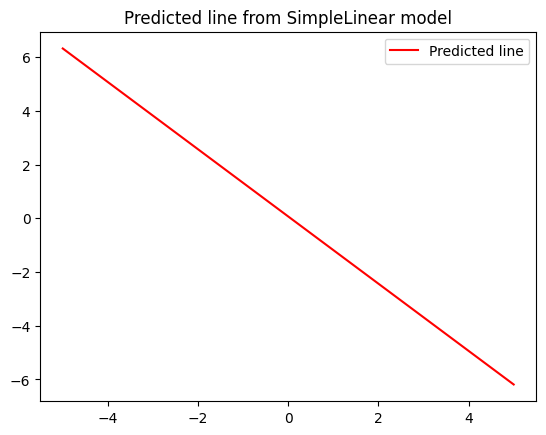

In [15]:
x_grid = torch.linspace(-5, 5, 100) # 100 evenly spaced points between -5 and 5
y_grid = simple_model(x_grid)

import matplotlib.pyplot as plt

plt.title("Predicted line from SimpleLinear model")
plt.plot(x_grid, y_grid.detach(), label="Predicted line", color="red")
plt.legend()
plt.show()

**Note:** In order to plot the predictions, we needed to call the `detach()` method on `y_pred` in

```python
plt.plot(x_grid, y_grid.detach(), label="Predicted line", color="red")
```

This is because:

* `y_pred` is part of a computation graph.
* Since it depends on learnable parameters `(theta_0, theta_1)`, PyTorch is tracking how it was computed in order to later compute gradients.

Matplotlib does not understand PyTorch’s computation graph. Plotting libraries expect ordinary numerical arrays, not tensors that carry gradient information.

`detach()` does not change the numerical values. It simply tells PyTorch:

> “Do not compute gradients through this tensor.”

We typically use `detach()` when:

* plotting
* logging values
* converting tensors to NumPy arrays
* performing operations that are not part of training

### Example: Multiple Linear Regression

Suppose our model is

$$
f_{\boldsymbol{\theta}}(\boldsymbol{x})
=
\boldsymbol{\theta}^\top \boldsymbol{x}
=
\theta_1 x_1 + \theta_2 x_2 + \ldots + \theta_p x_p.
$$

Here:

- $\boldsymbol{x} = (x_1, \ldots, x_p) \in \mathbb{R}^p$
- $\boldsymbol{\theta} = (\theta_1, \ldots, \theta_p) \in \mathbb{R}^p$
- The model is linear in the parameters

If we include an intercept term $\theta_0$, we can write

$$
f_{\boldsymbol{\theta}}(\boldsymbol{x})
=
\theta_0 + \boldsymbol{\theta}^\top \boldsymbol{x}.
$$

We can implement this model manually:

In [16]:
import torch
import torch.nn as nn

class MultipleLinear(nn.Module):

    def __init__(self, input_dim):
        super().__init__()

        # Intercept
        self.theta_0 = nn.Parameter(torch.randn(1))

        # Coefficient vector
        self.theta = nn.Parameter(torch.randn(input_dim))

    def forward(self, x):
        # x is assumed to have shape (batch_size, input_dim)
        return self.theta_0 + x @ self.theta

#### Using the model

As before, we instantiate the model as follows:

In [21]:
multiple_model = MultipleLinear(input_dim=3)
print("Initial parameters: \n",
      multiple_model.theta_0, "\n",
      multiple_model.theta)

Initial parameters: 
 Parameter containing:
tensor([-1.9100], requires_grad=True) 
 Parameter containing:
tensor([ 0.6056, -0.8906,  1.2317], requires_grad=True)


We can call the model as follows:

In [24]:
x = torch.tensor([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]], dtype=torch.float32)
y_pred = multiple_model(x)

print("Predicted values:", y_pred)

Predicted values: tensor([0.6097, 3.4501], grad_fn=<AddBackward0>)


#### Alternative Approach

PyTorch provides built-in modules that automatically manage parameters for us.  
Of particular importance is `nn.Linear`.

Instead of manually defining $\boldsymbol{\theta}$ and $\theta_0$, we can write:


In [30]:
class MultipleLinear_new(nn.Module):

    def __init__(self, input_dim):
        super().__init__()

        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        return self.linear(x)

The module `nn.Linear(input_dim, 1)` implements the function

$$
f_{\boldsymbol{\theta}}(\boldsymbol{x}) = W \boldsymbol{x} + b
$$

where:

* $W \in \mathbb{R}^{1 \times p}$ is a weight matrix
* $b \in \mathbb{R}$ is a bias term
* $\boldsymbol{\theta} = (W, b)$ collects all parameters

Thus, `nn.Linear` is simply a convenient implementation of multiple linear regression.

#### What does `nn.Linear` actually store?

Internally, the layer contains two learnable tensors:

In [34]:
multiple_model = MultipleLinear_new(input_dim=3)
print("Initial parameters: \n Weights,",
      multiple_model.linear.weight, "\n Bias,",
      multiple_model.linear.bias)

Initial parameters: 
 Weights, Parameter containing:
tensor([[ 0.2734, -0.2698,  0.1496]], requires_grad=True) 
 Bias, Parameter containing:
tensor([0.4725], requires_grad=True)


In this case:

* `weight` has shape $(1, p)$
* `bias` has shape $(1)$

These are automatically registered as learnable parameters.

#### Why this is helpful

Using `nn.Linear`:

* Avoids manually defining parameters
* Automatically handles batching
* Ensures parameters are correctly tracked
* Makes implementation of *neural networks* cleaner

For this reason, in practice we almost always use built-in modules rather than defining parameters by hand.

### Example: Feedforward Neural Network

Suppose our model has one hidden layer with $m$ hidden units:

$$
f_{\boldsymbol{\theta}}(\boldsymbol{x})
=
W_2 \, \sigma\!\left( W_1 \boldsymbol{x} + \boldsymbol{b}_1 \right)
+
\boldsymbol{b}_2.
$$

Here:

- $\boldsymbol{x} \in \mathbb{R}^d$
- $W_1 \in \mathbb{R}^{m \times d}$ is the first-layer weight matrix
- $\boldsymbol{b}_1 \in \mathbb{R}^m$ is the first-layer bias
- $\sigma$ is a nonlinear activation function (e.g. ReLU)
- $W_2 \in \mathbb{R}^{k \times m}$ is the second-layer weight matrix
- $\boldsymbol{b}_2 \in \mathbb{R}^k$ is the second-layer bias

The full parameter collection is

$$
\boldsymbol{\theta}
=
\{ W_1, \boldsymbol{b}_1, W_2, \boldsymbol{b}_2 \}.
$$

We can implement this model using PyTorch's built-in layers:


In [35]:
import torch
import torch.nn as nn

class FeedforwardNN(nn.Module):

    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()

        self.layer1 = nn.Linear(input_dim, hidden_dim)
        self.activation = nn.ReLU()
        self.layer2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h = self.layer1(x)
        h = self.activation(h)
        output = self.layer2(h)
        return output

#### Mathematical correspondence

The forward pass corresponds exactly to:

1. **First linear transformation:** $\boldsymbol{h} = W_1 \boldsymbol{x} + \boldsymbol{b}_1$
2. **Nonlinear activation:** $\boldsymbol{h} = \sigma(\boldsymbol{h})$
3. **Second linear transformation:** $f_{\boldsymbol{\theta}}(\boldsymbol{x}) = W_2 \boldsymbol{h} + \boldsymbol{b}_2$

#### Using the model

Exactly as before, we can use the model by instantiating. For plotting purposes, we set `input_dim = output_dim = 1`.

In [36]:
ffn_model = FeedforwardNN(input_dim=1, hidden_dim=5, output_dim=1)
print("Initial parameters: \n Layer 1 weights,",
      ffn_model.layer1.weight, "\n Layer 1 bias,",
      ffn_model.layer1.bias, "\n Layer 2 weights,",
      ffn_model.layer2.weight, "\n Layer 2 bias,",
      ffn_model.layer2.bias)

Initial parameters: 
 Layer 1 weights, Parameter containing:
tensor([[-0.8738],
        [-0.1453],
        [ 0.5115],
        [ 0.5221],
        [-0.5970]], requires_grad=True) 
 Layer 1 bias, Parameter containing:
tensor([ 0.9102, -0.8938,  0.5828,  0.2481,  0.5721], requires_grad=True) 
 Layer 2 weights, Parameter containing:
tensor([[ 0.1399, -0.0768,  0.3055,  0.3531, -0.1069]], requires_grad=True) 
 Layer 2 bias, Parameter containing:
tensor([-0.1049], requires_grad=True)


We can plot the initialised model as follows:

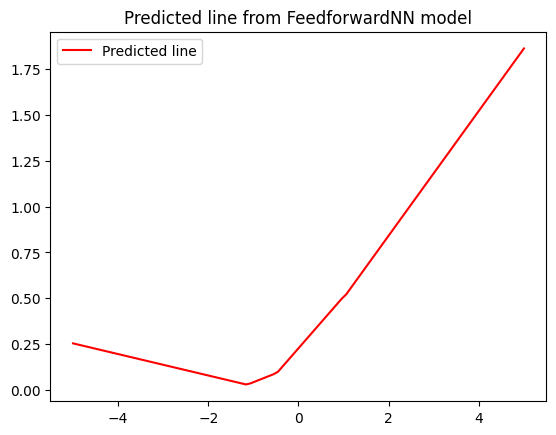

In [38]:
x_grid = torch.linspace(-5, 5, 100).unsqueeze(1) # 100 evenly spaced points between -5 and 5
y_grid = ffn_model(x_grid)

import matplotlib.pyplot as plt

plt.title("Predicted line from FeedforwardNN model")
plt.plot(x_grid, y_grid.detach(), label="Predicted line", color="red")
plt.legend()
plt.show()

#### Activation functions

Activation functions provide the **non-linearity** $\sigma$ in neural networks.

Without an activation function, a composition of linear layers would still be linear. The activation function is therefore what gives neural networks their expressive power.

Formally, in a feedforward network we apply

$$
\boldsymbol{h}
=
\sigma\!\left( W \boldsymbol{x} + \boldsymbol{b} \right),
$$

where $\sigma$ acts elementwise on the vector.

PyTorch provides many built-in [activation functions](https://docs.pytorch.org/docs/stable/nn.html#non-linear-activations-weighted-sum-nonlinearity). Here are a few of the most common ones plotted:


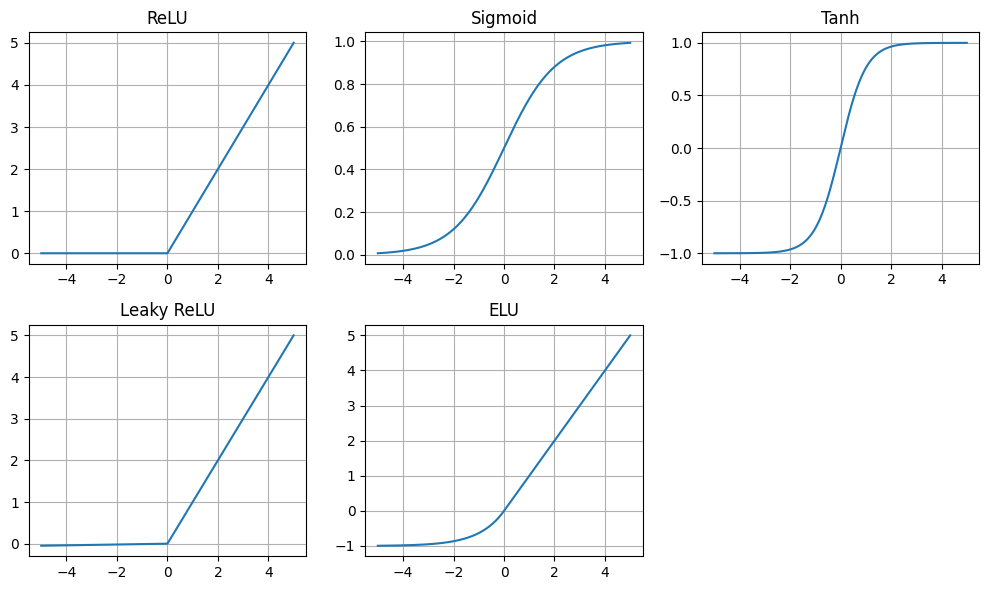

In [40]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Create input values
x = torch.linspace(-5, 5, 400)

# Define activation functions
activations = {
    "ReLU": nn.ReLU(),
    "Sigmoid": nn.Sigmoid(),
    "Tanh": nn.Tanh(),
    "Leaky ReLU": nn.LeakyReLU(),
    "ELU": nn.ELU()
}

# Create subplot grid
rows = 2
cols = 3
fig, axes = plt.subplots(rows, cols, figsize=(10, 6))
axes = axes.flatten()

# Plot each activation
for ax, (name, activation) in zip(axes, activations.items()):
    y = activation(x)

    ax.plot(x.detach(), y.detach())
    ax.set_title(name)
    ax.grid(True)

for i in range(len(activations), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

#### Which activation function should you use?

As a practical default, **ReLU** (`nn.ReLU()`) is usually a sensible first choice:

- It is simple and computationally efficient
- It avoids the saturation issues of sigmoid and tanh
- It helps mitigate vanishing gradient problems
- It works well in many standard feedforward architectures

For these reasons, ReLU is often the default activation in modern neural networks.

However, sometimes other activation functions are typically used:

- **Sigmoid** is commonly used in the *output layer* for binary classification.
- **Tanh** can be useful when zero-centred activations are beneficial.
- Variants such as **Leaky ReLU** may help if many neurons become inactive ("dying ReLU" problem).

There is no universally optimal activation function. ReLU is a strong baseline, but the appropriate choice ultimately depends on:

- The architecture
- The task
- The optimisation behaviour
- Empirical performance

In practice, model selection is often guided by experimentation.

## Regularisation (Ridge and LASSO)

In this final example, we consider the polynomial regression model

$$
f_{\boldsymbol{\theta}}(x)
=
\theta_0 + \theta_1 x + \theta_2 x^2 + \ldots + \theta_p x^p,
$$

where the parameter vector is

$$
\boldsymbol{\theta}
=
(\theta_0, \theta_1, \ldots, \theta_p)^\top
\in \mathbb{R}^{p+1}.
$$


### Using the design matrix

Given data $\{(x_i, y_i)\}_{i=1}^n$, define the **polynomial feature map**

$$
\Phi(x)
=
(1, x, x^2, \ldots, x^p)^\top.
$$

The corresponding **design matrix** is

$$
\boldsymbol{\Phi}
=
\begin{pmatrix}
1 & x_1 & x_1^2 & \ldots & x_1^p \\
1 & x_2 & x_2^2 & \ldots & x_2^p \\
\vdots & \vdots & \vdots & & \vdots \\
1 & x_n & x_n^2 & \ldots & x_n^p
\end{pmatrix}
\in \mathbb{R}^{n \times (p+1)}.
$$

The vector of predictions can then be written compactly as

$$
\hat{\boldsymbol{y}}
=
\boldsymbol{\Phi} \boldsymbol{\theta}.
$$

### Empirical Risk

The empirical risk (mean squared error) is

$$
\mathcal{R}_n(f_{\boldsymbol{\theta}})
=
\frac{1}{n}
\|
\boldsymbol{y}
-
\boldsymbol{\Phi}\boldsymbol{\theta}
\|_2^2.
$$

Minimising this without regularisation yields the ordinary least squares solution. However, when $p$ is large relative to $n$, the problem can become ill-posed or highly unstable.

This motivates **regularisation**.

### Ridge Regression (ℓ₂ Regularisation)

The ridge-regularised objective is

$$
\mathcal{R}_n(f_{\boldsymbol{\theta}})
+
\lambda
\|\boldsymbol{\theta}_{1:}\|_2^2,
$$

where

$$
\|\boldsymbol{\theta}_{1:}\|_2^2
=
\sum_{j=1}^p \theta_j^2.
$$

Importantly, we do **not** penalise the intercept $\theta_0$. Thus ridge regression solves

$$
\min_{\boldsymbol{\theta}}
\frac{1}{n}
\|
\boldsymbol{y}
-
\boldsymbol{\Phi}\boldsymbol{\theta}
\|_2^2
+
\lambda
\|\boldsymbol{\theta}_{1:}\|_2^2.
$$

**Effect:**  
- Coefficients are shrunk continuously toward zero.
- The solution is always unique.
- The optimisation problem remains smooth and convex.


### LASSO (ℓ₁ Regularisation)

The LASSO-regularised objective is

$$
\mathcal{R}_n(f_{\boldsymbol{\theta}})
+
\lambda
\|\boldsymbol{\theta}_{1:}\|_1,
$$

where

$$
\|\boldsymbol{\theta}_{1:}\|_1
=
\sum_{j=1}^p |\theta_j|.
$$

Thus LASSO solves

$$
\min_{\boldsymbol{\theta}}
\frac{1}{n}
\|
\boldsymbol{y}
-
\boldsymbol{\Phi}\boldsymbol{\theta}
\|_2^2
+
\lambda
\|\boldsymbol{\theta}_{1:}\|_1.
$$

**Effect:**  
- Encourages sparsity.
- Some coefficients become exactly zero.
- Produces simpler models.


#### Interpretation of $\lambda$

The regularisation parameter $\lambda \ge 0$ controls the trade-off:

- As $\lambda \to 0$, we recover the unregularised least squares solution.
- As $\lambda \to \infty$, the penalty dominates and coefficients shrink toward zero.

Thus varying $\lambda$ moves us along a spectrum:

- Small $\lambda$ → complex, flexible models.
- Large $\lambda$ → simpler, smoother models.


### Generating synthetic data

Our "true" data generating process is the model

$$
y = \sin(3 \pi x) + \epsilon, \qquad \epsilon \sim \mathcal{N}(0, (1/4)^2).
$$

In [46]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)

n = 50
x = torch.sort(2 * torch.rand(n) - 1)[0]   # uniform on [-1, 1]
y = torch.sin(3 * torch.pi * x) + 0.25 * torch.randn(n)

# Dense grid for plotting fitted curves
x_grid = torch.linspace(-1, 1, 400)



Plotting empirical data:

Text(0.5, 1.0, 'Synthetic data points')

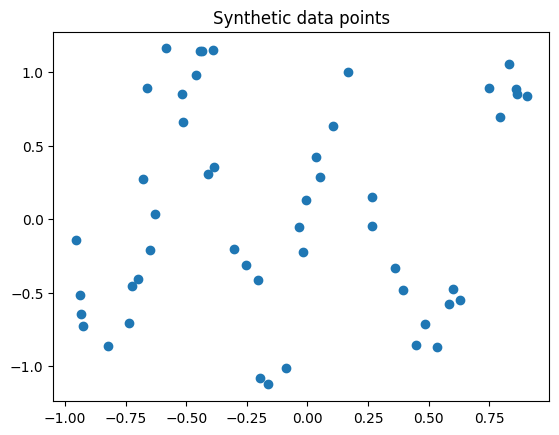

In [51]:
plt.plot(x, y, 'o')
plt.title("Synthetic data points")

### Defining the polynomial features

In [47]:
def poly_features(x_vec: torch.Tensor, degree: int) -> torch.Tensor:
    powers = torch.arange(0, degree + 1, dtype=x_vec.dtype)
    return x_vec.unsqueeze(1) ** powers.unsqueeze(0)


DEGREE = 12
Phi = poly_features(x, DEGREE)          # (n, p)
Phi_grid = poly_features(x_grid, DEGREE)

# Standardise non-intercept columns for numerical stability
col_mean = Phi[:, 1:].mean(dim=0)
col_std  = Phi[:, 1:].std(dim=0).clamp_min(1e-12)

Phi[:, 1:]      = (Phi[:, 1:]      - col_mean) / col_std
Phi_grid[:, 1:] = (Phi_grid[:, 1:] - col_mean) / col_std


### Defining the model

In [ ]:
class PolynomialModel(nn.Module):


    def __init__(self, degree: int):
        super().__init__()
        # One learnable weight per polynomial term (including the intercept)
        self.theta = nn.Parameter(torch.zeros(degree + 1))

    def forward(self, Phi):
        """
        Parameters
        ----------
        Phi : (n, degree + 1)  pre-computed polynomial design matrix

        Returns
        -------
        predictions : (n,)
        """
        return Phi @ self.theta


### Defining the regularised empirical risk functions

In [ ]:
def regularised_mse(
    model,
    predictions,
    targets,
    lam,
    penalty = "l2",
):
    """
    Compute  (1/n) Σ (yᵢ - ŷᵢ)²  +  λ · R(θ)

    where R(θ) penalises all coefficients *except* the intercept (θ₀):
        • penalty="l2"  ⟹  R = ‖θ₁:‖²   (ridge)
        • penalty="l1"  ⟹  R = ‖θ₁:‖₁   (lasso)
    """
    n = targets.shape[0]
    mse = (1.0 / n) * torch.sum((predictions - targets) ** 2)

    # Exclude the intercept from the penalty
    theta_rest = model.theta[1:]

    if penalty == "l2":
        reg = torch.sum(theta_rest ** 2)
    elif penalty == "l1":
        reg = torch.sum(torch.abs(theta_rest))
    else:
        raise ValueError(f"Unknown penalty '{penalty}'; choose 'l1' or 'l2'.")

    return mse + lam * reg



#### Training function

In [ ]:
def train_model(
    Phi,
    y,
    lam,
    penalty,
    lr = 0.01,
    epochs = 4000
):
    """
    Create a fresh PolynomialModel, train it with Adam, and return it.

    Parameters
    ----------
    Phi     : (n, p) design matrix
    y       : (n,)   targets
    lam     : regularisation strength  (λ ≥ 0)
    penalty : "l1" (lasso) or "l2" (ridge)
    lr      : Adam learning rate
    epochs  : number of gradient steps
    """
    model = PolynomialModel(degree=Phi.shape[1] - 1)
    optimiser = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        optimiser.zero_grad()
        y_hat = model(Phi)
        loss = regularised_mse(model, y_hat, y, lam=lam, penalty=penalty)
        loss.backward()
        optimiser.step()

    return model


### Sweep over $\lambda$

Since we want to assess how the regularisation parameter $\lambda$ affects LASSO and ridge output, we loop over different $\lambda$ values as follows:

In [ ]:
lambdas = torch.logspace(-4, 2, 80).tolist()
p = DEGREE + 1

ridge_coefs = torch.zeros(len(lambdas), p)
lasso_coefs = torch.zeros(len(lambdas), p)

print("Training ridge models …")
for i, lam in enumerate(lambdas):
    model = train_model(Phi, y, lam=lam, penalty="l2")
    ridge_coefs[i] = model.theta.detach()

print("Training lasso models …")
for i, lam in enumerate(lambdas):
    model = train_model(Phi, y, lam=lam, penalty="l1")
    lasso_coefs[i] = model.theta.detach()

# Pick a few λ values to show fitted curves
show_idx = [0, 10, 30, 60, 79]           # low → high regularisation
show_lams = [lambdas[i] for i in show_idx]

ridge_preds = [(Phi_grid @ ridge_coefs[i]).detach() for i in show_idx]
lasso_preds = [(Phi_grid @ lasso_coefs[i]).detach() for i in show_idx]



### Plotting

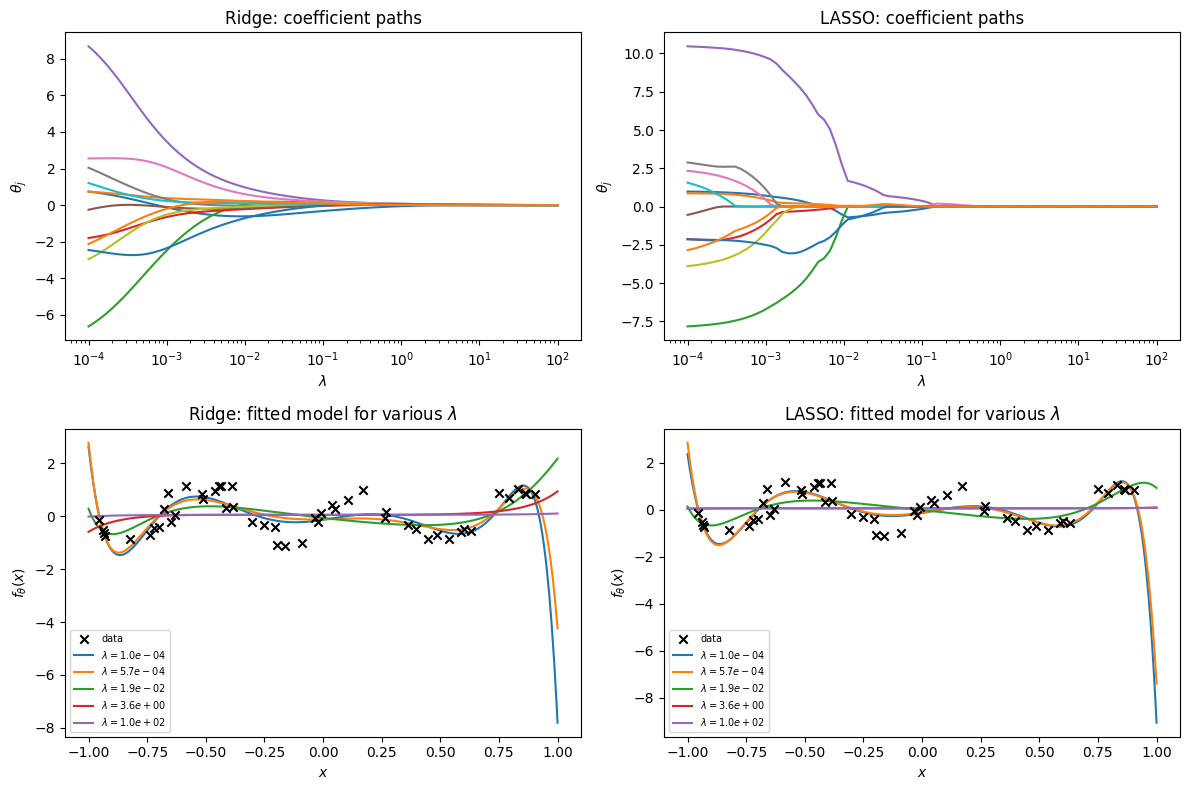

In [44]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Ridge coefficient paths
ax = axes[0, 0]
for j in range(1, p):
    ax.plot(lambdas, ridge_coefs[:, j].numpy())
ax.set_xscale("log")
ax.set_title("Ridge: coefficient paths")
ax.set_xlabel(r"$\lambda$")
ax.set_ylabel(r"$\theta_j$")

# Lasso coefficient paths
ax = axes[0, 1]
for j in range(1, p):
    ax.plot(lambdas, lasso_coefs[:, j].numpy())
ax.set_xscale("log")
ax.set_title("LASSO: coefficient paths")
ax.set_xlabel(r"$\lambda$")
ax.set_ylabel(r"$\theta_j$")

# Ridge fitted curves
ax = axes[1, 0]
ax.scatter(x.numpy(), y.numpy(), marker="x", color="k", zorder=5, label="data")
for lam_val, pred in zip(show_lams, ridge_preds):
    ax.plot(x_grid.numpy(), pred.numpy(), label=rf"$\lambda={lam_val:.1e}$")
ax.set_title(r"Ridge: fitted model for various $\lambda$")
ax.set_xlabel("$x$")
ax.set_ylabel(r"$f_\theta(x)$")
ax.legend(fontsize=7)

# Lasso fitted curves
ax = axes[1, 1]
ax.scatter(x.numpy(), y.numpy(), marker="x", color="k", zorder=5, label="data")
for lam_val, pred in zip(show_lams, lasso_preds):
    ax.plot(x_grid.numpy(), pred.numpy(), label=rf"$\lambda={lam_val:.1e}$")
ax.set_title(r"LASSO: fitted model for various $\lambda$")
ax.set_xlabel("$x$")
ax.set_ylabel(r"$f_\theta(x)$")
ax.legend(fontsize=7)

plt.tight_layout()
plt.show()